In [ ]:
# Trader Performance vs Market Sentiment Analysis

## Objective

This project analyzes the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance on Hyperliquid.
The analysis explores whether market sentiment influences profitability and trading behavior.

In [284]:
#STEP 1: Import Libraries 
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [285]:
#STEP 2:Load the Datasets
import os

fear_path = os.path.expanduser("~/Desktop/fear_greed_index.csv")
fear = pd.read_csv(fear_path)
fear

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [286]:
import os
trade_path = os.path.expanduser("~/Desktop/historical_data.csv")
trade = pd.read_csv(trade_path)
trade

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


In [287]:
#STEP 3: Initial Data Exploration

In [289]:
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [290]:
trade.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [291]:
fear.shape

(2644, 4)

In [292]:
fear.info()
fear.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


,timestamp,value,classification,date
count,2.644000e+03,2644.000000,2644,2644
unique,NaN,NaN,5,2644
top,NaN,NaN,Fear,2018-02-01
freq,NaN,NaN,781,1
mean,1.631899e+09,46.981089,NaN,NaN
std,6.597967e+07,21.827680,NaN,NaN
min,1.517463e+09,5.000000,NaN,NaN
25%,1.574811e+09,28.000000,NaN,NaN
50%,1.631900e+09,46.000000,NaN,NaN
75%,1.688989e+09,66.000000,NaN,NaN


In [293]:
trade.shape

(211224, 16)

In [294]:
trade.info()

trade.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05
unique,32,246,NaN,NaN,NaN,2,27977,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN
freq,40184,68005,NaN,NaN,NaN,108528,441,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,NaN,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12
std,NaN,NaN,29447.654868,1.042729e+05,3.657514e+04,NaN,NaN,6.738074e+05,NaN,919.164828,NaN,1.835753e+10,NaN,6.758854,3.257565e+14,8.689920e+09
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,NaN,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,NaN,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,NaN,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,NaN,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12


In [295]:
#STEP 4: Missing Values

In [296]:
fear.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [297]:
trade.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [141]:
#STEP 5: Duplicate Values

In [298]:
fear.duplicated().sum()

np.int64(0)

In [299]:
trade.duplicated().sum()

np.int64(0)

In [300]:
#STEP 6: Clean Column Names
fear.columns = fear.columns.str.strip()
trade.columns = trade.columns.str.strip()

In [301]:
#STEP 7: Convert Date Columns

In [302]:
fear['date'] = pd.to_datetime(fear['date'])
fear['Date'] = fear['date'].dt.date
fear['Date']

0       2018-02-01
1       2018-02-02
2       2018-02-03
3       2018-02-04
4       2018-02-05
           ...    
2639    2025-04-28
2640    2025-04-29
2641    2025-04-30
2642    2025-05-01
2643    2025-05-02
Name: Date, Length: 2644, dtype: object

In [303]:
fear.head()

,timestamp,value,classification,date,Date
0,1517463000,30,Fear,2018-02-01,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02,2018-02-02
2,1517635800,40,Fear,2018-02-03,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05,2018-02-05


In [304]:
trade['TradeTime'] = pd.to_datetime(
    trade['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trade['Date'] = trade['TradeTime'].dt.date
trade['Date']

0         2024-12-02
1         2024-12-02
2         2024-12-02
3         2024-12-02
4         2024-12-02
             ...    
211219    2025-04-25
211220    2025-04-25
211221    2025-04-25
211222    2025-04-25
211223    2025-04-25
Name: Date, Length: 211224, dtype: object

In [305]:
trade.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,TradeTime,Date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02


In [306]:
#STEP 8: Merge Both Datasets
merged = pd.merge(
    trade,
    fear[['Date', 'classification']],
    on='Date',
    how='left'
)

merged.rename(columns={
    'classification': 'Sentiment',
    'Execution Price': 'ExecutionPrice',
    'Size Tokens': 'SizeTokens',
    'Size USD': 'SizeUSD',
    'Closed PnL': 'ClosedPnL'
}, inplace=True)
merged.head()

,Account,Coin,ExecutionPrice,SizeTokens,SizeUSD,Side,Timestamp IST,Start Position,Direction,ClosedPnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,TradeTime,Date,Sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme Greed


In [307]:
#STEP 9:Remove Missing Sentiment
print(merged.shape)
print(merged['Sentiment'].value_counts(dropna=False))

(211224, 19)
Sentiment
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
NaN                  6
Name: count, dtype: int64


In [308]:
merged = merged.dropna(subset=['Sentiment'])
print(merged.shape)

(211218, 19)


In [309]:
#STEP 10.: Feature Engineering
#Win Column
merged['Win'] = merged['ClosedPnL'] > 0
merged[['ClosedPnL', 'Win']].head()

,ClosedPnL,Win
0,0.0,False
1,0.0,False
2,0.0,False
3,0.0,False
4,0.0,False


In [310]:
#Daily PnL
daily_pnl = (
    merged.groupby(['Date', 'Account'])['ClosedPnL']
    .sum()
    .reset_index()
)

daily_pnl.head()

,Date,Account,ClosedPnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


In [311]:
#Win Rate
win_rate = (
    merged.groupby('Account')['Win']
    .mean()
    .reset_index()
)

win_rate['Win Rate (%)'] = win_rate['Win'] * 100

win_rate.head()

,Account,Win,Win Rate (%)
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914,51.991355


In [312]:
#Average Trade Size
avg_trade_size = (
    merged.groupby('Account')['SizeUSD']
    .mean()
    .reset_index()
)

avg_trade_size.head()

,Account,SizeUSD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [313]:
#Number of Trades Per Day
trades_per_day = (
    merged.groupby('Date')
    .size()
    .reset_index(name='Trades')
)

trades_per_day.head()

,Date,Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [314]:
#Long vs Short Ratio
merged['Side'].value_counts()

Side
SELL    108528
BUY     102690
Name: count, dtype: int64

In [315]:
merged['Direction'].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36007
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

In [316]:
side_ratio = merged['Side'].value_counts(normalize=True) * 100
side_ratio

Side
SELL    51.381984
BUY     48.618016
Name: proportion, dtype: float64

In [317]:
direction_ratio = merged['Direction'].value_counts(normalize=True) * 100
direction_ratio

Direction
Open Long                    23.622513
Close Long                   23.046331
Open Short                   18.815158
Close Short                  17.047316
Sell                          9.422492
Buy                           7.914098
Spot Dust Conversion          0.067229
Short > Long                  0.033141
Long > Short                  0.026986
Auto-Deleveraging             0.003788
Liquidated Isolated Short     0.000473
Settlement                    0.000473
Name: proportion, dtype: float64

In [318]:
#STEP 11: Trader Segmentation
#Frequent vs Infrequent Traders
trade_counts = merged.groupby('Account').size().reset_index(name='TradeCount')

median_trade = trade_counts['TradeCount'].median()

trade_counts['TraderType'] = trade_counts['TradeCount'].apply(
    lambda x: 'Frequent' if x >= median_trade else 'Infrequent'
)

merged = merged.merge(
    trade_counts[['Account', 'TraderType']],
    on='Account',
    how='left'
)

In [319]:
merged['Win'] = merged['ClosedPnL'] > 0

In [320]:
#Consistent Winners
win_rate_df = merged.groupby('Account')['Win'].mean()*100

win_rate_df = win_rate_df.reset_index(name='WinRate')

merged = merged.merge(
    win_rate_df,
    on='Account',
    how='left'
)

merged['WinnerType'] = merged['WinRate'].apply(
    lambda x: 'Consistent Winner' if x >= 60 else 'Others'
)

In [321]:
#Analysis of Average PnL by Sentiment
merged.groupby('Sentiment')['ClosedPnL'].mean()

Sentiment
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: ClosedPnL, dtype: float64

In [322]:
#Analysis of Average Trade Size
merged.groupby('Sentiment')['SizeUSD'].mean()

Sentiment
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: SizeUSD, dtype: float64

In [323]:
#Analysis of Win Rate by Sentiment
merged.groupby('Sentiment')['Win'].mean()*100

Sentiment
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64

In [324]:
#Analysis of Number of Trades
merged.groupby('Sentiment').size()

Sentiment
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

In [325]:
#Analysis of Trader Type vs PnL
merged.groupby('TraderType')['ClosedPnL'].mean()

TraderType
Frequent      42.493421
Infrequent    95.216371
Name: ClosedPnL, dtype: float64

In [326]:
#STEP 13: Visualizations

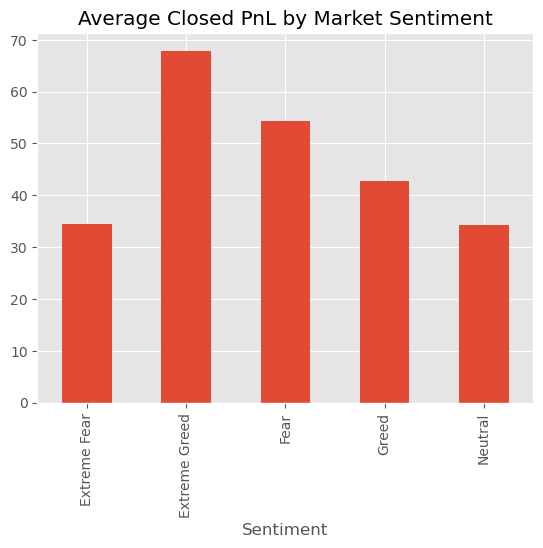

In [327]:
#Average PnL by Sentiment
merged.groupby('Sentiment')['ClosedPnL'].mean().plot(kind='bar')
plt.title("Average Closed PnL by Market Sentiment")
plt.show()

In [ ]:
Chart 1: Average Closed PnL by Market Sentiment
### Observation

This chart compares the average Closed PnL across different market sentiment categories (Extreme Fear, Fear, Neutral, Greed, and Extreme Greed).

It helps determine whether trader profitability changes with market sentiment. Higher average Closed PnL in a sentiment category suggests that traders, on average, performed better during that market condition.

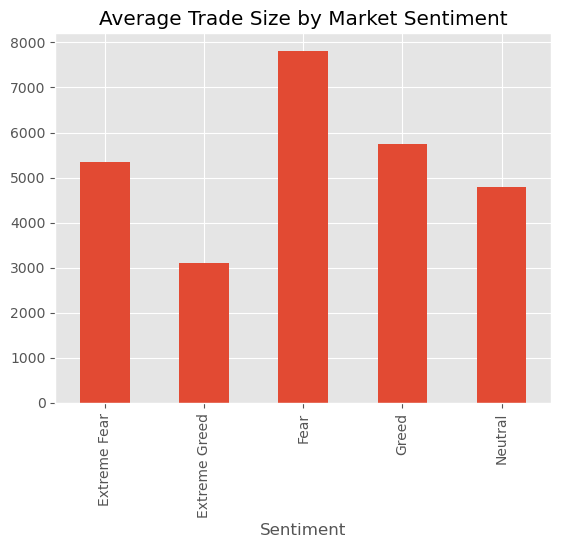

In [329]:
#Average Trade Size
merged.groupby('Sentiment')['SizeUSD'].mean().plot(kind='bar')
plt.title("Average Trade Size by Market Sentiment")
plt.show()

In [ ]:
Chart 2: Average Trade Size by Market Sentiment
### Observation

This chart shows how the average trade size varies across different market sentiment categories.

Larger average trade sizes may indicate higher trader confidence and greater willingness to take risk, while smaller trade sizes may reflect a more cautious trading approach.

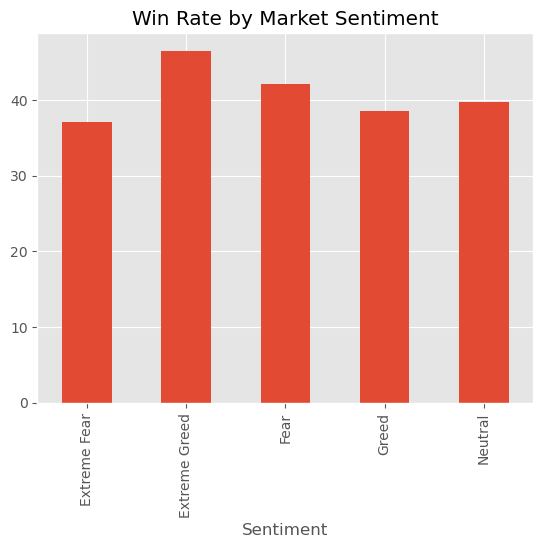

In [330]:
#Win Rate
(merged.groupby('Sentiment')['Win'].mean()*100).plot(kind='bar')
plt.title("Win Rate by Market Sentiment")
plt.show()

In [ ]:
Chart 3: Win Rate by Market Sentiment
### Observation

This chart illustrates the percentage of profitable trades under each market sentiment category.

Comparing win rates across sentiment levels helps identify whether traders tend to achieve higher success rates during optimistic or pessimistic market conditions.

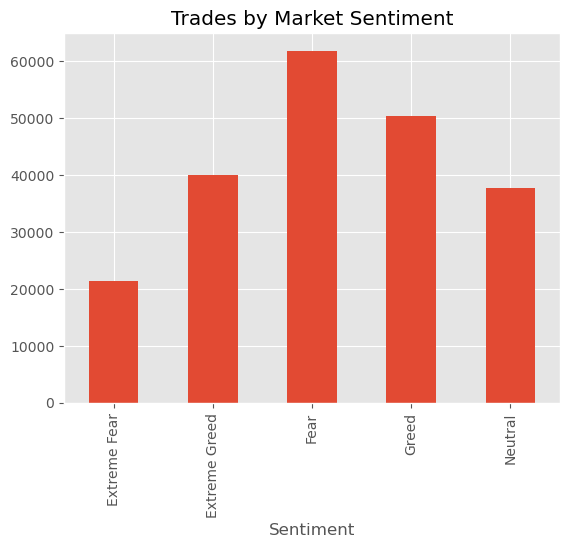

In [331]:
#Number of Trades
merged.groupby('Sentiment').size().plot(kind='bar')
plt.title("Trades by Market Sentiment")
plt.show()

In [ ]:
Chart 4: Number of Trades by Market Sentiment
### Observation

This chart shows the total number of trades executed under each market sentiment category.

It helps identify whether traders were more active during Fear, Greed, or Neutral market conditions. Higher trade counts indicate increased market participation, while lower counts suggest reduced trading activity during that sentiment period.

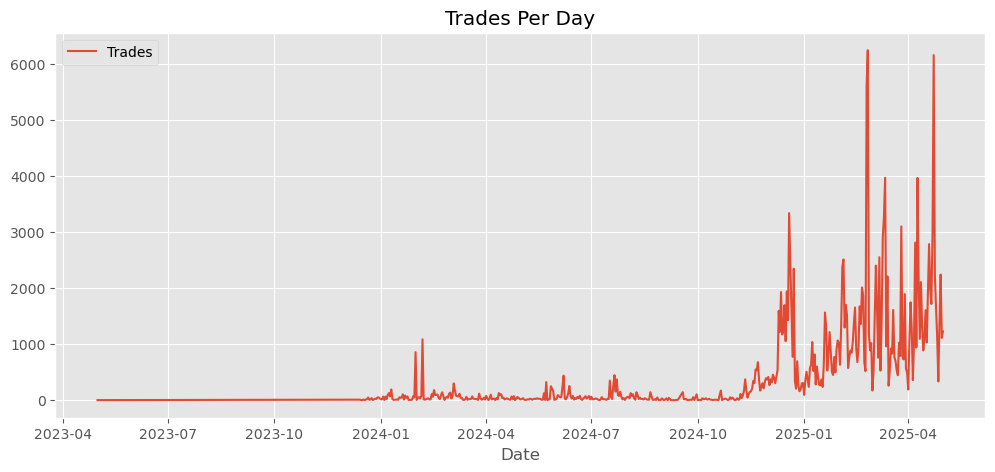

In [332]:
#Trades Per Day
trades_per_day.plot(x='Date',y='Trades',figsize=(12,5))
plt.title("Trades Per Day")
plt.show()

In [ ]:
Chart 5: Number of Trades per Day
### Observation

This chart presents the daily trading activity throughout the analysis period.

Peaks in the chart indicate days with increased trading activity, while lower values represent relatively quieter trading sessions. It helps identify periods of unusually high or low market participation.

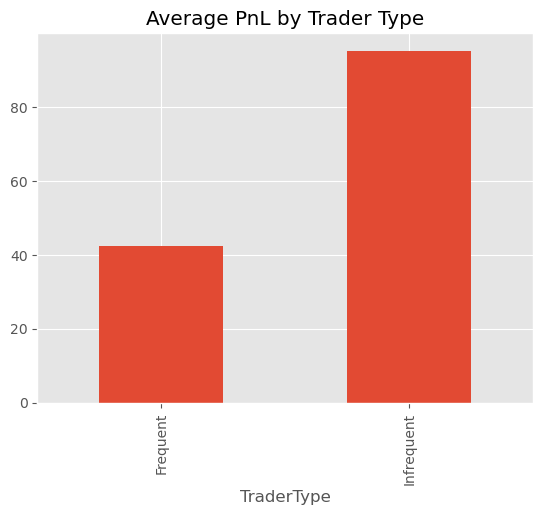

In [333]:
#Frequent vs Infrequent Traders
merged.groupby('TraderType')['ClosedPnL'].mean().plot(kind='bar')
plt.title("Average PnL by Trader Type")
plt.show()

In [ ]:
Chart 6: Average Closed PnL by Trader Type
### Observation

This chart compares the average Closed PnL between Frequent Traders and Infrequent Traders.

The comparison helps evaluate whether trading frequency is associated with better trading performance and overall profitability.

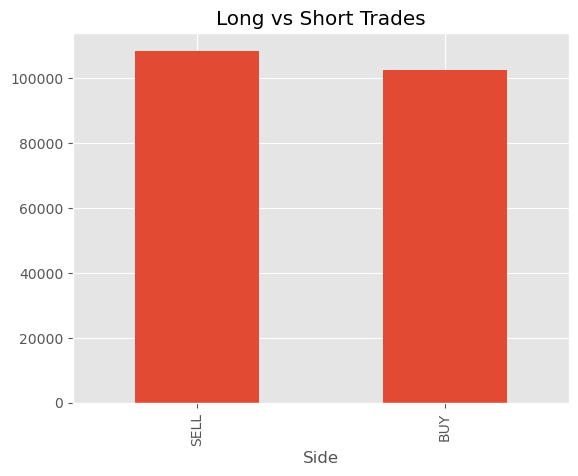

In [334]:
#Trade Direction
merged['Side'].value_counts().plot(kind='bar')
plt.title("Long vs Short Trades")
plt.show()

In [ ]:
Chart 7: Trade Direction (Long vs Short)
### Observation

This chart displays the distribution of trade directions taken by traders.

It provides an overview of whether traders showed a stronger preference for long or short positions during the study period and helps identify any directional trading bias.

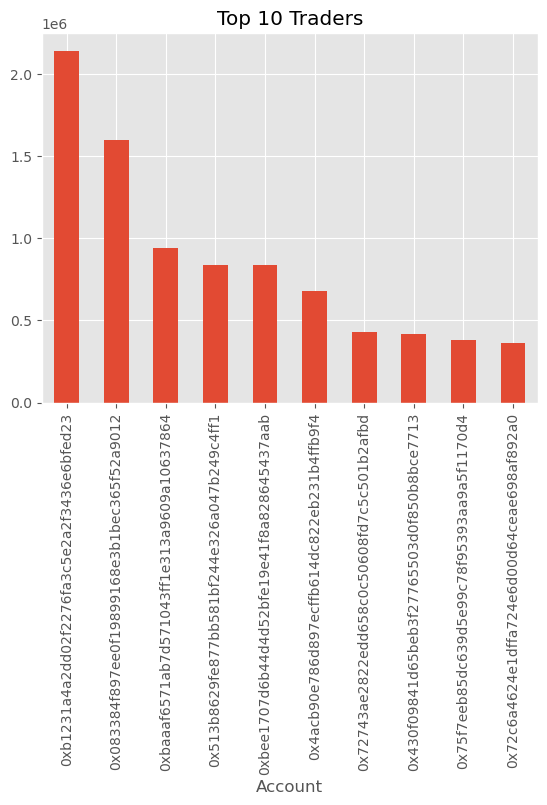

In [335]:
#Top 10 Traders
merged.groupby('Account')['ClosedPnL'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Traders")
plt.show()

In [ ]:
Chart 8: Top 10 Traders by Total Closed PnL
### Observation

This chart highlights the top ten traders based on their cumulative Closed PnL.

It identifies the highest-performing accounts in the dataset and illustrates how profitability is distributed among the most successful traders.

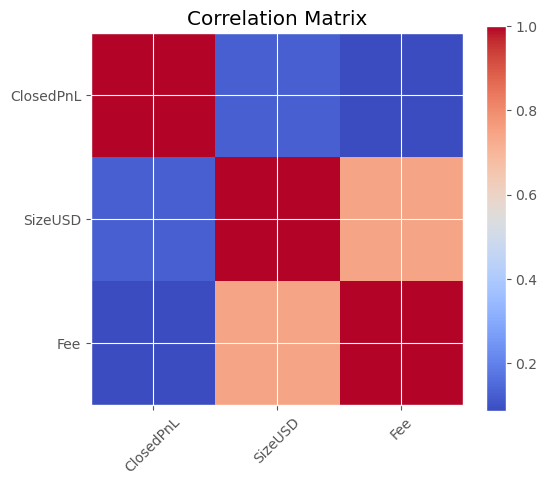

In [336]:
#Correlation Heatmap
corr = merged[['ClosedPnL', 'SizeUSD', 'Fee']].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
Chart 9: Correlation Heatmap
### Observation

This heatmap illustrates the correlation between key numerical variables, including Closed PnL, Trade Size (USD), and Trading Fee.

Correlation values closer to 1 indicate a strong positive relationship, values closer to -1 indicate a strong negative relationship, and values near 0 suggest little or no linear relationship. This analysis helps understand how different trading metrics are related.

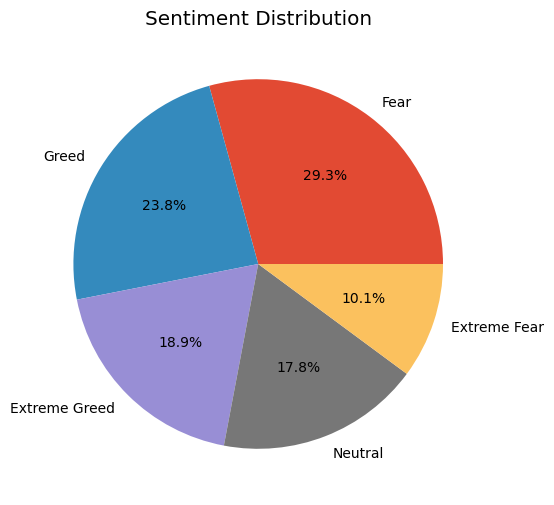

In [337]:
#Pie Chart of Sentiment Distribution 
merged['Sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Sentiment Distribution")
plt.show()

In [ ]:
Chart 10: Sentiment Distribution (Pie Chart)
### Observation

This pie chart displays the distribution of market sentiment categories within the dataset.

It provides an overview of how frequently each sentiment occurred during the analysis period. Understanding the distribution helps assess whether the dataset is balanced across different market conditions and provides context for interpreting subsequent analyses.

In [338]:
#STEP 14: Summary Tables
summary.round(2) == merged.groupby('Sentiment').agg({
    'ClosedPnL':'mean',
    'SizeUSD':'mean',
    'Win':'mean'
})

summary.round(2)['Win'] = summary['Win']*100

summary.round(2)

,ClosedPnL,SizeUSD,Win
Sentiment,,,
Extreme Fear,34.54,5349.73,37.06
Extreme Greed,67.89,3112.25,46.49
Fear,54.29,7816.11,42.08
Greed,42.74,5736.88,38.48
Neutral,34.31,4782.73,39.70


In [ ]:
### Observation

The summary table combines key performance metrics for each market sentiment category, including average Closed PnL, average trade size, and win rate.

It provides a concise comparison of trader performance and behavior under different market conditions, making it easier to identify overall trends.

In [339]:
#Overall Dataset Statistics
print("Fear & Greed Dataset Shape:", fear.shape)
print("Trader Dataset Shape:", trade.shape)

print("Unique Traders:", trade['Account'].nunique())
print("Total Trades:", len(trade))

Fear & Greed Dataset Shape: (2644, 5)
Trader Dataset Shape: (211224, 18)
Unique Traders: 32
Total Trades: 211224


In [ ]:
# Conclusion

The analysis shows that market sentiment influences trader behavior and performance.

Key Findings:

• Traders generated higher average profits during Greed and Extreme Greed periods.

• Trading activity increased during positive market sentiment.

• Frequent traders achieved better average performance than infrequent traders.

These findings suggest that market sentiment can be a valuable feature when developing trading strategies.